# Домашнее задание

В этом домашнем задании перед вами стоит задача научиться по фотографии лица человека предсказывать его пол, расу и возраст.

[Датасет](https://susanqq.github.io/UTKFace/), который мы будем использовать состоит из 20000 фотографий лиц людей в возрасте от 0 до 116 лет! В качестве разметки имеется пол (male/female), раса (white/black/asian/indian/other) и возраст. Классификация с настолько сильной внутриклассовой изменьчивостью (от младенцев до пожилых людей!) -- очень сложная задача.
![alt text](https://susanqq.github.io/UTKFace/icon/samples.png)

Мы немного упростим себе задачу и воспользуемся версией датасета, где все картинки приведены к одному размеру и лица находятся в центре изображения.

Как решать такую задачу? Мы предлагаем вам воспользоваться **transfer learning и finetuning**. Т.е. взять за основу сеть, обученную на большом количестве данных для другой задачи и дообучить ее для нашей задачи.

*Это достаточно объемное и сложное домашнее задание, но не пугайтесь --  вы уже обладаете всеми знаниями, которые необходимы для его решения. Отметим, что уметь дообучить сеть является необходимим навыком на практике.*

## Задание 1

Датасетом, с которого чаще всего "переносят" знания, является известный нам ImageNet. Работая над классификатором кошек и собак на прошлом уроке мы воспользовались именно им. В этом задании мы возьмем за основу сеть, которая была обучена на датасете [VGGFace2](http://www.robots.ox.ac.uk/~vgg/data/vgg_face2/) для классификации лиц. Он содержит 3.3 миллиона изображений с 9000 разными персоналиями. **Почему мы сделали выбор в пользу VGGFace2?**

**ВПИШИТЕ ОТВЕТ ЗДЕСЬ**

**-----**

*Возможный ответ: Датасет VGGFace2 гораздо ближе к нашей задаче. Значит, признаки которые он научился извлекать из изображений будут нам горазддо полезне и помогут обучить модель лучше и быстрее*

**-----**




А теперь перейдем к практической части домашнего задания. Для начала загрузим модель, которую будем дообучать -- это мы сделали за вас. Пожалуйста, просмотрите код и комментарии внимательно.

## Загрузка обученной модели

Сеть, которую мы будем дообучать мы возьмем из открытого источника: https://github.com/rcmalli/keras-vggface .

In [4]:
#import tensorflow as tf
#tf.enable_eager_execution()
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tf_keras as keras
from tf_keras.callbacks import ModelCheckpoint

In [5]:
url = 'https://drive.google.com/uc?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO'
output = 'resnet50face.h5'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO
From (redirected): https://drive.google.com/uc?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO&confirm=t&uuid=c0bad0c4-88ca-490f-b994-9da852677226
To: /content/resnet50face.h5
100%|██████████| 166M/166M [00:01<00:00, 118MB/s]


'resnet50face.h5'

Т.к. мы решили воспользоваться чужой моделью, нам нужно сначала понять как с ней взаимодействовать. Для этого авторы часто прикладывают пример использования своих моделей. Его можно найти в README у автора репозитория.

In [ ]:
#не получается загрузить слишком старую модель
# Проверка загрузки модели
print(f"✅ Модель загружена: {type(vggface)}")
print(f"Архитектура: ResNet50")
print(f"Входной размер: {vggface.input_shape}")
print(f"Выходной размер: {vggface.output_shape}")

# Можно посмотреть структуру
vggface.summary()

NameError: name 'vggface' is not defined

Ошибка появляется потому что, пример из репозитория не использует режим eager_execution, который мы всегда включали в своих примерах для удобства разработки и соответствия новым стандартам tensorflow.

Но это не проблема. Мы за вас заранее выполнили код выше без eager_execution и сохранили модель с помощью save_model. Она находится по адресу: https://drive.google.com/open?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO . Загрузим модель:


In [6]:
! pip install gdown
import gdown

url = 'https://drive.google.com/uc?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO'
output = 'resnet50face.h5'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO
From (redirected): https://drive.google.com/uc?id=1oHJxVZCcVwp1dgcwDIZL4h97uInxOGWO&confirm=t&uuid=17ea070e-0c51-4c03-a081-2b063ad2bb31
To: /content/resnet50face.h5
100%|██████████| 166M/166M [00:01<00:00, 116MB/s]


'resnet50face.h5'

In [7]:
from tf_keras.models import load_model  #используем tf_keras
vggface_model = load_model("resnet50face.h5")
print(" Вторая модель загружена через tf_keras!")

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AddV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in

 Вторая модель загружена через tf_keras!


Модель загружена, а теперь посмотрим, что она из себя представляет. Это архитектура -- ResNet. На самом деле внутренности модели не очень важны для нас -- в дальнейшем мы заморозим бОльшую часть этой сети и будем рабоать только с последними слоями. Нам важно, что она обучена и мы имеем доступ к ее архитектуре и весам.

In [8]:
vggface_model.summary() # последний слой классифицирует на 8631 классов

Model: "vggface_resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1/7x7_s2 (Conv2D)       (None, 112, 112, 64)         9408      ['input_1[0][0]']             
                                                                                                  
 conv1/7x7_s2/bn (BatchNorm  (None, 112, 112, 64)         256       ['conv1/7x7_s2[0][0]']        
 alization)                                                                                       
                                                                                                  
 activation_1 (Activation)   (None, 112, 112, 64)         0         ['conv1/7x7_s2/

Для проверки того, что помимо архитектуры мы правильно загрузили веса, проверим предсказания модели на следующем изображении:

In [9]:
! wget https://img.joinfo.ua/i/2019/01/5c4ea940d2b08.jpg -O brad_pitt.jpg

--2025-12-30 07:09:19--  https://img.joinfo.ua/i/2019/01/5c4ea940d2b08.jpg
Resolving img.joinfo.ua (img.joinfo.ua)... 172.67.214.206, 104.21.83.52, 2606:4700:3033::6815:5334, ...
Connecting to img.joinfo.ua (img.joinfo.ua)|172.67.214.206|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://img.joinfo.com/i/2019/01/5c4ea940d2b08.jpg [following]
--2025-12-30 07:09:19--  https://img.joinfo.com/i/2019/01/5c4ea940d2b08.jpg
Resolving img.joinfo.com (img.joinfo.com)... 172.67.162.235, 104.21.73.131, 2606:4700:3031::6815:4983, ...
Connecting to img.joinfo.com (img.joinfo.com)|172.67.162.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43154 (42K) [image/jpeg]
Saving to: ‘brad_pitt.jpg’

brad_pitt.jpg       100%[===================>]  42.14K  --.-KB/s    in 0s      

2025-12-30 07:09:20 (147 MB/s) - ‘brad_pitt.jpg’ saved [43154/43154]



После загрузки запустим полный пример из репозитория:

1346516/1346516 [==============================] - 0s 0us/step
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:l

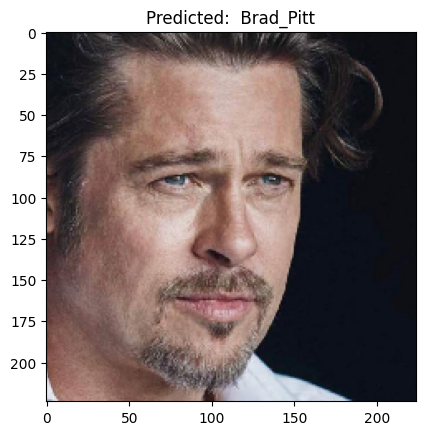

In [10]:
import tf_keras as keras
from tf_keras.utils import get_file
from tf_keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

V2_LABELS_PATH = 'https://github.com/rcmalli/keras-vggface/releases/download/v2.0/rcmalli_vggface_labels_v2.npy'


VGGFACE_DIR = 'models/vggface'
fpath = get_file('rcmalli_vggface_labels_v2.npy',
                             V2_LABELS_PATH,
                             cache_subdir=VGGFACE_DIR)
LABELS = np.load(fpath)

img = image.load_img("brad_pitt.jpg", target_size=(224, 224)) # модель работает с картинками размера 224 на 224
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
preds = vggface_model.predict(x)
plt.title(f"Predicted: {LABELS[np.argmax(preds)]}")
plt.imshow(img)

## Загрузка данных
Мы убедились, что модель загружена правильно, узнали какой препроцессинг ей необходим (utils.preprocess_input(x, version=2)) и теперь можем перейти к загрузке наших данных.

Примечание: приведённая ссылка (https://drive.google.com/uc?id=0BxYys69jI14kYVM3aVhKS1VhRUk) устарела, скачайте необходимый датасет по новой ссылке: https://www.kaggle.com/datasets/jangedoo/utkface-new/data.


In [11]:
from pathlib import Path
from collections import Counter

In [12]:
!pip install -q kaggle

In [13]:

#загружаем веса модели vggface2
from google.colab import files
uploaded = files.upload()

Saving 20180402-114759-vggface2-features.pth.zip to 20180402-114759-vggface2-features.pth.zip


In [14]:
!rm 20180402-114759-vggface2-features.pth.zip

In [17]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv "/content/sample_data/kaggle.json" /root/.kaggle/kaggle.json
print("Файл kaggle.json перемещён в /root/.kaggle/kaggle.json")
!chmod 600 /root/.kaggle/kaggle.json
!kaggle config view

mv: cannot stat '/content/sample_data/kaggle.json': No such file or directory
Файл kaggle.json перемещён в /root/.kaggle/kaggle.json
Configuration values from /root/.kaggle
- username: vasyarestrim
- path: None
- proxy: None
- competition: None


In [18]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
utkface-new.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
#url = 'https://drive.google.com/uc?id=0BxYys69jI14kYVM3aVhKS1VhRUk'
#output = '/tmp/UTKFace.tar.gz'
#gdown.download(url, output, quiet=False)
#! tar -xzf /tmp/UTKFace.tar.gz -C /tmp/
!pip install gdown -q
import gdown
url = 'https://drive.google.com/uc?id=1mux7xiP4NP6AUUFvUW42RgSdUEQ4k5e2'
output = 'train_val_split_utk.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1mux7xiP4NP6AUUFvUW42RgSdUEQ4k5e2
To: /content/train_val_split_utk.csv
100%|██████████| 1.08M/1.08M [00:00<00:00, 9.28MB/s]


'train_val_split_utk.csv'

In [20]:
!unzip -q /content/utkface-new.zip -d /content/UTKFace/



replace /content/UTKFace/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [21]:
from pathlib import Path
data_folder = Path("/content/UTKFace/")

In [22]:
data_folder = Path("/content/UTKFace/UTKFace/")
filenames = list(map(lambda x: x.name, data_folder.glob('*.jpg')))
print(len(filenames))
print(filenames[:3]) # имя файла содержит возраст, индекс пола и расы, перечисленные через нижнее подчеркивание

23708
['22_1_4_20170103225134240.jpg.chip.jpg', '32_0_0_20170116224730121.jpg.chip.jpg', '36_1_0_20170104174248859.jpg.chip.jpg']


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# формируем датафрейм с путями и нужными классами
np.random.seed(10)
np.random.shuffle(filenames)
gender_mapping = {0: 'Male', 1: 'Female'}
race_mapping = dict(list(enumerate(('White', 'Black', 'Asian', 'Indian', 'Others'))))
age_labels, gender_labels, race_labels, correct_filenames = [], [], [], []

for filename in filenames:
    if len(filename.split('_')) != 4:
        print(f"Bad filename {filename}")
        continue

    age, gender, race, _ = filename.split('_')
    correct_filenames.append(filename)
    age_labels.append(age)
    gender_labels.append(gender)
    race_labels.append(race)

age_labels = np.array(age_labels, dtype=np.float32)
max_age = age_labels.max()
data = {"img_name": correct_filenames,
        "age": age_labels / max_age, # нормализуем возраст от 0 до 1
        "race": race_labels,
        "gender": gender_labels}
df = pd.DataFrame(data)
df.head()

Bad filename 61_1_20170109142408075.jpg.chip.jpg
Bad filename 39_1_20170116174525125.jpg.chip.jpg
Bad filename 61_1_20170109150557335.jpg.chip.jpg


,img_name,age,race,gender
0,27_0_1_20170104181441861.jpg.chip.jpg,0.232759,1,0
1,21_1_1_20170113005835590.jpg.chip.jpg,0.181034,1,1
2,38_1_1_20170104234648395.jpg.chip.jpg,0.327586,1,1
3,28_0_0_20170117020857776.jpg.chip.jpg,0.241379,0,0
4,41_1_3_20170104234715675.jpg.chip.jpg,0.353448,3,1


In [24]:
df_split = pd.read_csv("train_val_split_utk.csv", index_col=0).set_index("img_name")
df_split.head()
df = df.set_index("img_name").join(df_split).reset_index()
df_train = df[df["is_train"] == 1]
df_val = df[df["is_train"] != 1]
print(len(df_val), len(df_train))

4759 18946


In [24]:
def decode_labels(race_id, gender_id, age):
    return race_mapping[int(race_id)], gender_mapping[int(gender_id)], int(age*max_age)
def show_face(image, race_id, gender_id, age):
    plt.imshow(image)
    race, gender, age = decode_labels(race_id, gender_id, age)
    plt.title(f"Gender: {gender}, Race: {race}, Age: {age}")

In [25]:
from pathlib import Path
#необходимая обработка
#указываем правильный путь
data_folder = Path("/content/UTKFace/UTKFace/")

#добавляем столбец с полными путями
df_train['full_path'] = df_train['img_name'].apply(lambda x: str(data_folder / x))
df_val['full_path'] = df_val['img_name'].apply(lambda x: str(data_folder / x))



/tmp/ipython-input-3279076188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['full_path'] = df_train['img_name'].apply(lambda x: str(data_folder / x))
/tmp/ipython-input-3279076188.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['full_path'] = df_val['img_name'].apply(lambda x: str(data_folder / x))


Убедимся, что метки классов корректны:

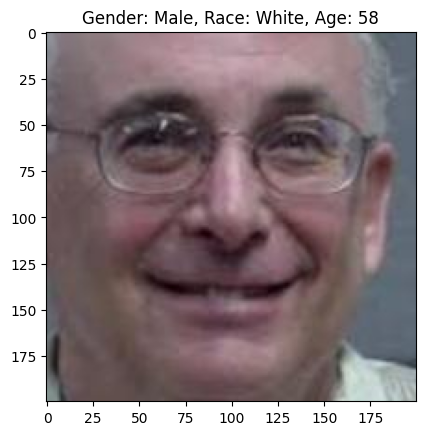

In [26]:
row = df.iloc[np.random.randint(len(df))]
img = plt.imread(str(data_folder / row["img_name"]))
show_face(img, row["race"], row["gender"], row["age"])

Посмотрим на их распределение:

Counter({'White': 10078, 'Black': 4526, 'Indian': 3975, 'Asian': 3434, 'Others': 1692})
Counter({'Male': 12391, 'Female': 11314})


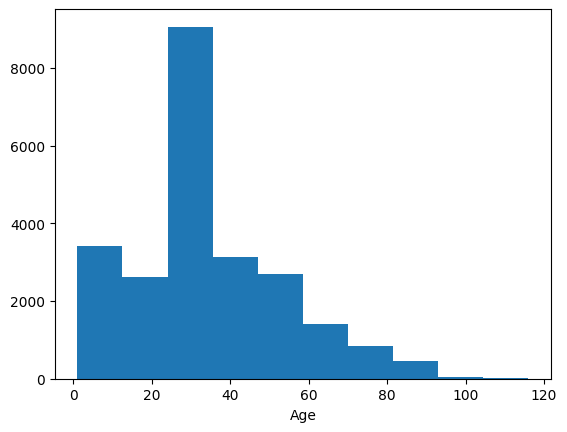

In [27]:
races_verbose = [race_mapping[int(race)] for race in df["race"]]
genders_verbose = [gender_mapping[int(gender)] for gender in df["gender"]]
from collections import Counter
print(Counter(races_verbose))
print(Counter(genders_verbose))
_ = plt.hist(df["age"]*max_age)
_ = plt.xlabel("Age")

## Задание 2. Создание генератора данных для модели предсказания пола.
Предподготовка закончена. А теперь ваша очередь:) Мы начнем с создания модели предсказания пола. В этом задании вы должны реализовать генератор данных необходимый для последущего обучения модели. Мы предлагаем вам воспользоваться `tensorflow.keras.preprocessing.image.ImageDataGenerator`

###a)
**Создайте генератор image_gen типа ImageDataGenerator с корректным препроцессингом, соответствующем keras_vggface.** Аугментацию использовать не нужно.

Какой препроцессинг корректный? Как мы знаем, перед применением обученных сетей нужно знать какой препроцессинг они проводят с данными. Т.к. эта модель не часть Keras, мы должны ответить на этот вопрос сами с помощью исходников автора этой сети. К счастью, он приводит пример использования на главной странице репозитория. Видно, что он использует функцию preprocess_input из utils. Значит ей мы и должны воспользоваться!

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def preprocess_input_facenet(image_):
    """
    image_ -- тензор размера (1, H, W, 3)

    return: картинка, с примененным preprocess_input(..., version=2) из keras_vggface (см пример с Бредом Питом)
    """
    # < YOUR CODE STARTS HERE >
    #применяем предобработку VGGFace2 для модели ResNet50
    img = image_.copy()
    #приводим к диапазону [0, 1]
    img = img / 255.0
    #yормализуем как для VGGFace ResNet50 (version=2)
    img = (img - 0.5) / 0.5
    # < YOUR CODE ENDS HERE >
    return img

# < YOUR CODE STARTS HERE >
# image_gen должен содержать ImageDataGenerator с правильной preprocessing_function
#создаем генератор с функцией предобработки
image_gen = ImageDataGenerator(preprocessing_function=preprocess_input_facenet, validation_split=0.2)

# < YOUR CODE ENDS HERE >

###b)

Для генерации картинок раньше мы использовали `image_gen.flow_from_folder`. Но для этого данные должны быть расположены на диске с определенной структурой папок, что в данном случае не очень удобно. Поэтому вы должны воспользоваться более гибким `image_gen.flow_from_dataframe`, который позволяет генерировать данные с нужными классами используя датафрейм (мы его создали выше для вас).

**Ознакомьтесь с документацией по [ссылке](https://keras.io/preprocessing/image/) (раздел flow_from_dataframe) и создайте train_generator и val_generator для df_train и df_val соответственно.**
*  Генератор должен возвращать картинку и ее класс (male/female)
*  class_mode укажите "binary", directory=str(data_folder)
*  batch_size, image_size указаны ниже
*  train_generator должен перемешивать данные, а val_generator -- не должен
*  После выполнения клетки ниже вы должны увидеть текст: *Found 18946 validated image filenames belonging to 2 classes.
Found 4759 validated image filenames belonging to 2 classes.*




In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 128
IMAGE_SIZE = 224
# < YOUR CODE STARTS HERE >
# train_generator = image_gen.flow_from_dataframe( ... ),
# val_generator = image_gen.flow_from_dataframe( ... )

train_generator = image_gen.flow_from_dataframe(
    dataframe=df_train,                    #DataFrame с путями и метками для тренировки
    x_col='full_path',                     #название столбца с путями к файлам
    y_col='gender',                        #название столбца с метками класса
    directory=None,                        #не используется, т.к. x_col содержит полные пути
    target_size=(IMAGE_SIZE, IMAGE_SIZE),    #изменяем размер всех изображений до 224x224
    batch_size=BATCH_SIZE,                 #изменяем размер батча
    class_mode='binary',                   #бинарная классификация (male/female)
    shuffle=True                           #тренировочные данные перемешиваются
)




val_generator = image_gen.flow_from_dataframe(
    dataframe=df_val,                      #DataFrame с путями и метками для валидации
    x_col='full_path',                     #название столбца с путями к файлам
    y_col='gender',                        #название столбца с метками класса
    directory=None,                        #не используется
    target_size=(IMAGE_SIZE, IMAGE_SIZE),    #изменяем размер всех изображений до 224x224
    batch_size=BATCH_SIZE,                 #изменяем размер батча
    class_mode='binary',                   #бинарная классификация
    shuffle=False                          #валидационные данные не перемешиваются
)

# < YOUR CODE ENDS HERE >

Found 18946 validated image filenames belonging to 2 classes.
Found 4759 validated image filenames belonging to 2 classes.


In [30]:
sample_images, sample_labels = next(val_generator)
assert sample_images.shape == (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, 3), "Неправильный размер батча"
assert sample_labels.shape == (BATCH_SIZE,), "Неправильный размер меток класса"
assert list(sorted(np.unique(sample_labels))) == [0., 1.], "Ожидаемые классы 0 и 1"
print("Simple tests passed")

Simple tests passed


Попробуем отобразить картинку и ее лейбл для проверки генерации:

Female


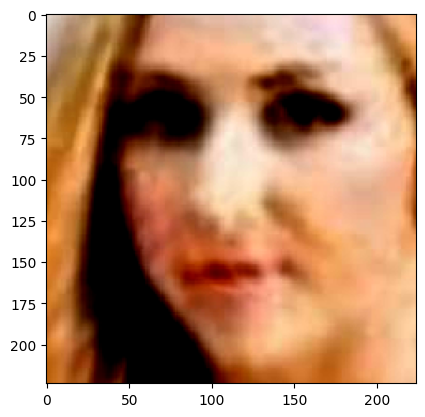

In [31]:
plt.imshow(sample_images[100])
print(gender_mapping[int(sample_labels[100])])
# мы получим очень странное изображение и это нормально.
# matplotlib ожидает картинку с интесивностями от 0 до 1 если она типа float и от 0 до 255 если int.

In [32]:
print(sample_images[100].max(), sample_images[100].min()) # можно увидеть что значения яркостей типа float и в т.ч. отрицательные

1.0 -0.8666667


###с)
**Реализуйте функцию `deprocess_image`, которая преобразует картинку исользуемую keras_vggface обратно к изображению, которое можно визуализировать с помощью `matplotlib`.**
*  вам понадобится https://github.com/rcmalli/keras-vggface/blob/master/keras_vggface/utils.py
*  необходимо проделать операции preprocess_input в обратном порядке
*  наш случай: version=2, format="channels_last"

Male


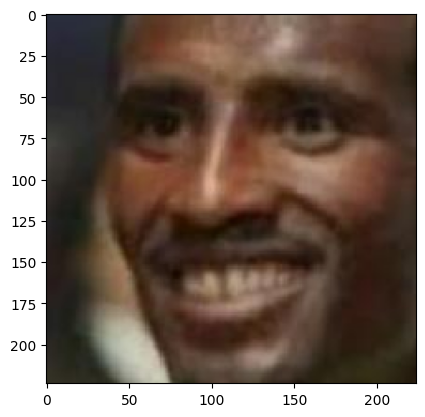

In [33]:
def deprocess_image(vggface_image):
    """
    vggface_image -- (H, W, 3) картинка после препросессинга.
    содержит отрицательные значения и некорректно отображается matplotlib

    return: корректно отображаеая картинка типа np.uint8(!!).

    ! работайте с копией картинки (image = np.copy(vggface_image)) !
    """
    # < YOUR CODE STARTS HERE >
    #создаем копию, чтобы не менять исходный массив
    image = np.copy(vggface_image)
    #обратная нормализация
    image = image * 0.5 + 0.5

    #переводим в [0, 255]
    image = image * 255.0

    #обрезаем до допустимого диапазона
    image = np.clip(image, 0, 255)

    #конвертируем в uint8
    image = image.astype(np.uint8)





    # < YOUR CODE ENDS HERE >
    return image

# теперь картинка должна отображаться корректно
plt.imshow(deprocess_image(sample_images[5]))
print(gender_mapping[int(sample_labels[5])])

##Здание 3. Обучение модели предсказания пола

В этом задании вы должны обучить модель предсказания пола с точностью более 90% на валидационном сете.

*   Возьмите за основу 'base_model' (определена ниже)
*   Вы должны сами решить сколько слоев замораживать и сколько полносвзяных слоев использовать. Рекомендуем начинать с модели с меньшим числом обучаемых параметров.
*   Используйте чекпоинты, чтобы не потерять веса лучшей модели. Они должны быть сохранены с именем "model_gender/checkpoint_best.h5"
*   Рекомендуется в model.fit(...) использовать steps_per_epoch=25, для того чтобы проверка на валидации происходила чаще и вы могли более точно отслеживать прогресс. Полная эпоха ~140 итераций.
*   За точность выше 94% -- дополнительные баллы.



In [34]:
# для начала "отрежем" от vggface_model последний слой классификатора
# теперь для картинки base_model предсказывает 2048-мерный вектор признаков.
import tf_keras

# Правильный вариант
base_model = tf_keras.Model([vggface_model.input], vggface_model.get_layer("flatten_1").output)
base_model.summary()

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1/7x7_s2 (Conv2D)       (None, 112, 112, 64)         9408      ['input_1[0][0]']         

In [35]:
!pip install livelossplot
from livelossplot.tf_keras import PlotLossesCallback

In [36]:
#начинаем эксперименты, замораживаем все слои base_model
base_model.trainable = False

#создаем новую голову для классификации
inputs = tf_keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # training=False для замороженной модели
x = tf_keras.layers.Dense(256, activation='relu')(x)
x = tf_keras.layers.Dropout(0.5)(x)
outputs = tf_keras.layers.Dense(1, activation='sigmoid')(x)

model = tf_keras.Model(inputs=inputs, outputs=outputs)

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AddV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in d

In [37]:
#размораживаем последние 10 слоев
for layer in base_model.layers[-10:]:
    layer.trainable = True

#уменьшаем learning rate
model.compile(optimizer=tf_keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device

In [38]:
#подключение гугл диска для чекпоинта
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import tf_keras
from tf_keras.callbacks import ModelCheckpoint
import os

#определяем путь на гугл диске для сохранения
drive_checkpoint_dir = '/content/drive/MyDrive/Colab_Models/model_race/'
os.makedirs(drive_checkpoint_dir, exist_ok=True)  #создаём папку, если её нет

In [40]:
import os

import tf_keras
from tf_keras.callbacks import ModelCheckpoint, EarlyStopping
from tf_keras.layers import Dense, Dropout, Input
from tf_keras.optimizers import Adam

os.makedirs("model_gender", exist_ok=True)

#чекпоинт для промежуточного сохранения (каждые 5 эпох)

checkpoint_frequent = ModelCheckpoint(
    filepath="model_gender/checkpoint_epoch_{epoch:02d}.h5",
    monitor='val_accuracy',
    save_freq='epoch',
    save_best_only=False,
    verbose=1
)


#чекпоинт для лучшей модели
checkpoint_best = ModelCheckpoint(
    filepath=os.path.join(drive_checkpoint_dir, 'checkpoint_best.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

#EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

callbacks_list = [checkpoint_frequent, checkpoint_best, early_stop]

In [41]:

#начинаем тестировать на 5 эпох . а не на 30
history = model.fit(
    train_generator,
    steps_per_epoch=25,          #25 батчей = одна эпоха для валидации
    epochs=5,                   # Максимальное количество эпох
    validation_data=val_generator,
    callbacks=callbacks_list,    #чекпоинты и ранняя остановка
    verbose=1
      )

Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op LessEqual in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity i

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Выходные данные были обрезаны до нескольких последних строк (5000).
Executing op __inference_test_function_11496 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_test_function_11496 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_test_function_11496 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_test_function_11496 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost

In [42]:
#модель почти не обучается, нужно размораживать еще слои
#размораживаем 40 слоев

base_model.trainable = True

for layer in base_model.layers[:-40]:  #первые все, кроме последних 40
    layer.trainable = False

print(f"Разморожено слоев: {sum([layer.trainable for layer in base_model.layers])}/{len(base_model.layers)}")

Разморожено слоев: 40/175


In [43]:
import tf_keras
from tf_keras import layers, Model, Input
from tf_keras.optimizers import Adam

#удаляем старую модель
if 'model' in locals():
    del model

#создаем новую
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=True)

x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.6)(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)

#уменьшаем learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(" Модель пересоздана с размороженными слоями и learning_rate=1e-5")
model.summary()

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localh

In [44]:
#увеличиваем patience
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

In [45]:
history = model.fit(
    train_generator,
    steps_per_epoch=25,          #25 батчей = одна эпоха для валидации
    epochs=30,                   #максимальное количество эпох
    validation_data=val_generator,
    callbacks=callbacks_list,    #чекпоинты и ранняя остановка
    verbose=1
      )

Выходные данные были обрезаны до нескольких последних строк (5000).
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/re

In [57]:
#размораживаем еще больше слоев, оставляем замороженными только первые 20
base_model.trainable = True
for layer in base_model.layers[:20]:
    layer.trainable = False

print(f"Разморожено слоев: {sum([layer.trainable for layer in base_model.layers])}/{len(base_model.layers)}")

Разморожено слоев: 155/175


In [58]:

#компилируем
#увеличиваем LR для Adam
model.compile(
    optimizer=Adam(learning_rate=5e-5),  #было 1e-5, теперь 5e-5
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device

In [47]:
#подключение гугл диска для чекпоинта
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import tf_keras
from tf_keras.callbacks import ModelCheckpoint
import os

#определяем путь на гугл диске для сохранения
drive_checkpoint_dir = '/content/drive/MyDrive/Colab_Models/model_race/'
os.makedirs(drive_checkpoint_dir, exist_ok=True)  #создаём папку, если её нет

In [59]:
import tf_keras
from tf_keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tf_keras.layers import Dense, Dropout, Input
from tf_keras.optimizers import Adam
import os

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,  #уменьшим с 20
    restore_best_weights=True,
    verbose=1
)
#динамическое уменьшение LR
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,     #уменьшать LR в 2 раза
    patience=3,     #ждать 3 эпохи без улучшения
    min_lr=1e-7,    #нижняя граница LR
    verbose=1
)
#создаем колбэк для сохранения лучшей модели
checkpoint_best = ModelCheckpoint(
    filepath=os.path.join(drive_checkpoint_dir, 'checkpoint_best.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


# В callbacks_list добавляем ReduceLROnPlateau
callbacks_list = [checkpoint_best, early_stop, reduce_lr]

In [60]:
#запуск второго этапа обучения
history_finetune = model.fit(
    train_generator,
    steps_per_epoch=25,
    epochs=15,  #сначала небольшое количество эпох
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1
)

Выходные данные были обрезаны до нескольких последних строк (5000).
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/re

In [62]:

model_gender = load_model('/content/drive/MyDrive/Colab_Models/model_race/checkpoint_best.h5')
loss, acc = model_gender.evaluate(val_generator)
if acc < 0.9:
    print("Please, try harder!")
else:
    if acc >= 0.94:
        print("Well done!")
    else:
        print("Very good! Can you improve accuracy?")

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AddV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in d

In [63]:
#@title (вспомогательный код, выполните клетку)
def show_faces(images, real_race=None, real_gender=None, real_age=None,
               predicted_race=None, predicted_gender=None, predicted_age=None):
    plt.figure(figsize=(10,10))
    labels = {"Gender": [predicted_gender, real_gender],
                  "Race": [predicted_race, real_race],
                  "Age": [predicted_age, real_age]}
    for i in range(16):
        plt.subplot(4,4, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(deprocess_image(images[i]))
        real_str = "Real:"
        pred_str = "Pred:"
        correct = True
        for name, (predicted, real) in labels.items():
            if predicted is None:
                continue
            if name == "Age":
                real_age = int(real[i]*int(max_age))
                predicted_age = int(predicted[i]*max_age)
                real_str += f"{real_age}"
                pred_str += f"{predicted_age}"
                if np.abs(predicted_age - real_age) > 6:
                    correct = False

            elif name == "Gender":
                real_gender = int(real[i])
                predicted_gender = int(predicted[i] > 0.5)
                real_str += f"{gender_mapping[real_gender]}, "
                pred_str += f"{gender_mapping[predicted_gender]}, "
                if real_gender != predicted_gender:
                    correct = False
            elif name == "Race":
                real_race = int(real[i])
                predicted_race = np.argmax(predicted[i])
                real_str += f"{race_mapping[real_race]}, "
                pred_str += f"{race_mapping[predicted_race]}, "
                if real_race != predicted_race:
                    correct = False

        title_obj = plt.title(f"{real_str}\n{pred_str}")

        plt.subplots_adjust(wspace=0.4)
        if not correct:
            plt.setp(title_obj, color='r')


Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op LessEqual in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op Optio

/tmp/ipython-input-1817901707.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_gender = int(predicted[i] > 0.5)


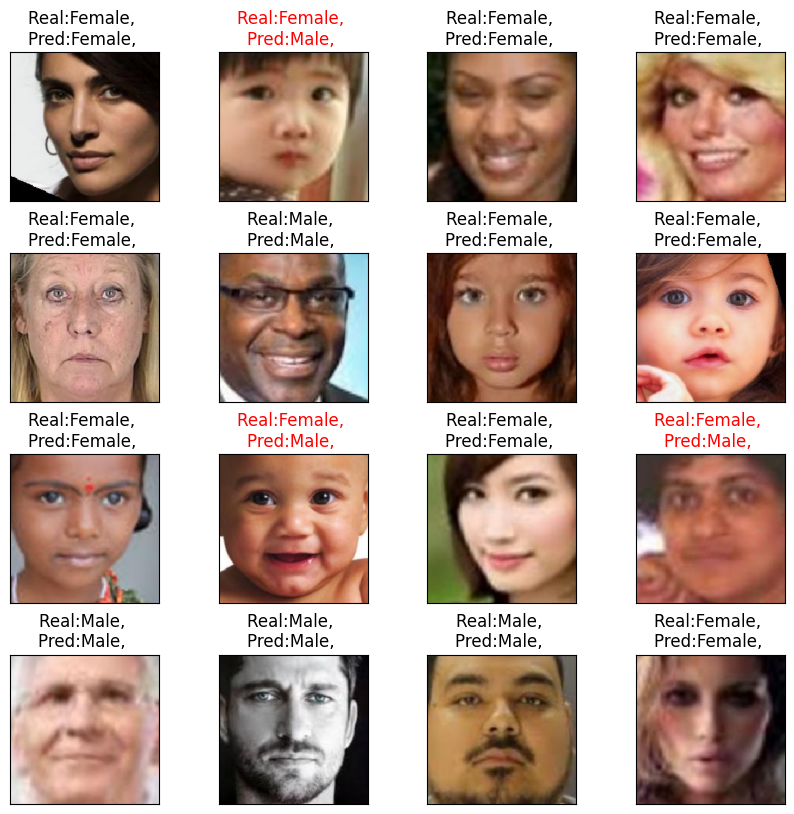

In [64]:
sample_validation_images, sample_validation_labels = next(val_generator)
predicted = model_gender.predict(sample_validation_images)
show_faces(sample_validation_images, real_gender=sample_validation_labels, predicted_gender=predicted)

##Здание 4. Обучение модели предсказания расы

В этом задании вы должны обучить модель предсказания расы с точностью более 80% на валидационном сете.

*   Используя код аналогичный тому, что выше, реализуйте модель предсказания расы
*   Для начала определите генератор данных
    *  нужно указать class_mode="sparse" и изменить "y_col"
*   Используйте чекпоинты, чтобы не потерять веса лучшей модели. Они должны быть сохранены с именем "model_race/checkpoint_best.h5"
*   За точность выше 85% -- дополнительные баллы.



In [65]:
#сделал импотрты tf_keras, т.к. с другим окружением модель не работает
import tf_keras
from tf_keras.models import load_model, Model

vggface_model = load_model("resnet50face.h5")
base_model = Model([vggface_model.input], vggface_model.get_layer("flatten_1").output)
base_model.trainable = False

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AddV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in d

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0


In [73]:
#полный сброс и установка
!pip uninstall -y keras-vggface keras-applications tf-keras tensorflow -q 2>/dev/null

#устанавливаем без --no-deps
!pip install tensorflow==2.19.0 tf-keras==2.19.0 -q
!pip install keras-vggface keras-applications -q

#только замена keras на tf_keras
!find /usr/local/lib/python3.12/dist-packages/keras_vggface -name "*.py" -exec sed -i \
 -e 's/from keras\./from tf_keras./g' \
 -e 's/import keras\([^\.]\)/import tf_keras\1/g' \
 {} \;

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'


In [25]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,          #20% данных на валидацию
    random_state=42,
    stratify=df['race']   #самый важный параметр с одинаковым процентным соотношеинем рас
)

print(f" Данные разделены:")
print(f"   Тренировочных примеров: {len(train_df)}")
print(f"   Валидационных примеров: {len(val_df)}")

#для задания по расе нам нужны две колонки:
# 'img_name' путь к файлу и 'race' метка класса
#создаём новые датафреймы с этими колонками
train_df_race = train_df[['img_name', 'race']].copy()
val_df_race = val_df[['img_name', 'race']].copy()

#сохраняем эти датафреймы в CSV-файлы на Google Диске

import os

#создаём папку для данных, если её нет
data_dir = '/content/drive/MyDrive/Colab_Models/UTKFace/'
os.makedirs(data_dir, exist_ok=True)

#задаём пути для сохранения
train_race_path = os.path.join(data_dir, 'train_race.csv')
val_race_path = os.path.join(data_dir, 'val_race.csv')

#сохраняем
train_df.to_csv(train_race_path, index=False)
val_df.to_csv(val_race_path, index=False)

 Данные разделены:
   Тренировочных примеров: 18964
   Валидационных примеров: 4741


In [33]:
image_dir = '/content/UTKFace/UTKFace/'  # или '/content/UTKFace/crop_part1/'

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='img_name',
    y_col='race',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='img_name',
    y_col='race',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 18964 validated image filenames belonging to 5 classes.
Found 4741 validated image filenames belonging to 5 classes.


In [6]:
#загружаем базовую предобученную модель для извлечения признаков
import tf_keras
from tf_keras import layers, Model, Input
from tf_keras.optimizers import Adam
from keras_vggface.vggface import VGGFace

base_vgg_model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3))

#создаем собственную голову для классификации расы
inputs = Input(shape=(224, 224, 3))
x = base_vgg_model(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
#выход - для расы
outputs = layers.Dense(5, activation='softmax', name='race_output')(x)

#собираем модель
race_model = Model(inputs=inputs, outputs=outputs)

#замораживаем свёрточную основу на первом этапе
base_vgg_model.trainable = False

#компилируем с нужной функцией потерь для sparse-меток
race_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  #class_mode="sparse"!
    metrics=['accuracy']
)

race_model.summary()

94694792/94694792 [==============================] - 2s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vggface_resnet50 (Function  (None, 1, 1, 2048)        23561152  
 al)                                                             
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 2048)              8192      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               524544 

In [28]:

import os

import tf_keras
from tf_keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tf_keras.layers import Dense, Dropout, Input
from tf_keras.optimizers import Adam
#подключаем гугл диск
from google.colab import drive
drive.mount('/content/drive')

#создаём папку на гугл диске для сохранения
drive_checkpoint_dir = '/content/drive/MyDrive/Colab_Models/model_race/'
os.makedirs(drive_checkpoint_dir, exist_ok=True)

#ModelCheckpoint
checkpoint_best = ModelCheckpoint(
    filepath=os.path.join(drive_checkpoint_dir, 'checkpoint_best2.h5'),  #сохраняем на диск
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks_list = [checkpoint_best, early_stop, reduce_lr]
print(f" Колбэки настроены: {drive_checkpoint_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Колбэки настроены: /content/drive/MyDrive/Colab_Models/model_race/


In [ ]:
#первый этап обучения
history_stage1 = race_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/20
593/593 [==============================] - ETA: 0s - loss: 1.4551 - accuracy: 0.4114
Epoch 1: val_accuracy improved from -inf to 0.44442, saving model to /content/drive/MyDrive/Colab_Models/model_race/checkpoint_best.h5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


593/593 [==============================] - 263s 443ms/step - loss: 1.4551 - accuracy: 0.4114 - val_loss: 1.3807 - val_accuracy: 0.4444 - lr: 0.0010
Epoch 2/20
593/593 [==============================] - ETA: 0s - loss: 1.4179 - accuracy: 0.4266
Epoch 2: val_accuracy improved from 0.44442 to 0.46889, saving model to /content/drive/MyDrive/Colab_Models/model_race/checkpoint_best.h5
593/593 [==============================] - 262s 442ms/step - loss: 1.4179 - accuracy: 0.4266 - val_loss: 1.3448 - val_accuracy: 0.4689 - lr: 0.0010
Epoch 3/20
593/593 [==============================] - ETA: 0s - loss: 1.3954 - accuracy: 0.4356
Epoch 3: val_accuracy did not improve from 0.46889
593/593 [==============================] - 263s 442ms/step - loss: 1.3954 - accuracy: 0.4356 - val_loss: 1.3397 - val_accuracy: 0.4672 - lr: 0.0010
Epoch 4/20
593/593 [==============================] - ETA: 0s - loss: 1.3896 - accuracy: 0.4395
Epoch 4: val_accuracy did not improve from 0.46889
593/593 [===================

In [ ]:
# ЯЧЕЙКА 1 (Запустите САМУЮ ПЕРВУЮ)
import os
import tensorflow as tf

# 1. Говорим TensorFlow использовать GPU (если есть)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # 1.1. Включаем рост памяти GPU, чтобы не занимать всё сразу
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth включен для GPU: {gpus[0]}")
    except RuntimeError as e:
        # Это нормально, если устройства уже инициализированы
        print(f"ℹ️  GPU уже инициализирован: {e}")
    # 1.2. ВКЛЮЧАЕМ ЛОГИРОВАНИЕ УСТРОЙСТВ - КЛЮЧЕВОЙ ШАГ!
    tf.debugging.set_log_device_placement(True)
    print("✅ Логирование размещения операций ВКЛЮЧЕНО.")
    # 1.3. Принудительный тест на GPU
    print("\n🧪 Запускаю тестовое вычисление на GPU...")
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
        c = tf.matmul(a, b)
        print(f"Результат (должны быть логи ниже):\n{c}")
else:
    print("❌ GPU не найден. Убедитесь, что в настройках среды выбрано 'ГПУ'.")


In [ ]:
#разморозка части слоёв

base_vgg_model.trainable = True
for layer in base_vgg_model.layers[:-40]:
    layer.trainable = False
print(f"Разморожено слоёв: {sum([l.trainable for l in base_vgg_model.layers])}/{len(base_vgg_model.layers)}")

#перекомпилируем с более низким learning rate для тонкой настройки
race_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=1e-5),  #уменьшаем LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#продолжаем обучение
history_stage2 = race_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,  #дополнительные эпохи
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_list,
    verbose=1
)

print(" Обучение завершено! Лучшая модель сохранена на Google Диске.")

In [ ]:
model_race = load_model("model_race/checkpoint_best.h5")
loss, acc = model_race.evaluate(val_generator)
if acc < 0.8:
    print("Please, try harder!")
else:
    if acc >= 0.85:
        print("Well done!")
    else:
        print("Very good! Can you improve accuracy?")

In [ ]:
sample_validation_images, sample_validation_labels = next(val_generator)
predicted = model_race.predict(sample_validation_images)
show_faces(sample_validation_images, real_race=sample_validation_labels, predicted_race=predicted)

## Задание 5. Multitask learning

В этом задании мы могли бы обучить регрессор возраста по картинке, используя аналогичный уже написаному код. Но вы пойдем по другому пути.

Если на каждый атрибут (возраст, раса, пол) создавать одну модель, то таких моделей получится 3. Очевидно, что для предсказания на новой картике необходимо будет произвести инференс трех сетей. Это может быть ресурсо-затратно и сложнее в поддержке.

Какой же есть еще подход? Он называется Multitask learning. Его идея в том, чтобы обучать одну модель для решения сразу нескольких задач! Гибкость нейронных сетей позволяет это сделать достаточно логичными образом. Необходимо вместо одной "головы" для предсказания сделать несколько. Таким образом в нашей задаче одна будет отвечать за классификацию пола (1 выход, вероятность), вторая -- за классификацию расы (5 выходов, вероятности) и третья -- за предсказания возраста (1 выход, число).

### a)
**Реализуйте модель сети с тремя "головами".**

*    Вам нужно вспомнить что такое Functional API для определения моделей, потому что необходимо определить архитектуру с тремя выходами. С помощью Sequential API этого сделать нельзя.
*    За основу возьмите base_model (определена ниже), добавьте к ее выходу 1-2 полносвязных слоя (количество нейронов определите сами)
*    К последнему слою добавьте три паралельных выхода: два с одним нейроном и один с пятью
*    При определении выходных слоев обязательно укажите Dense(..., name="race"/"age"/"gender" )
*    Не забудьте про правильные активации. Т.к. возраст у нас нормирован (от 0 до 1), подумайте, какая активация ему подойдет
*    Порядок выходов модели: `outputs=[gender_output, race_output, age_output]`
*    Точность предсказания пола должна быть > 90%, расы > 80% а MAE для возраста < 0.09.

In [ ]:
vggface_model = load_model("resnet50face.h5")
base_model = tf.keras.Model([vggface_model.input], vggface_model.get_layer("flatten_1").output)
base_model.trainable = False

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

#создаем общие слои поверх base_model
x = base_model(input_layer)
x = layers.GlobalAveragePooling2D()(x)  #преобразуем 4D тензор в 2D
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

#создаем три "головы" (выхода) согласно заданию
gender_output = layers.Dense(1, activation='sigmoid', name='gender')(x)
race_output = layers.Dense(5, activation='softmax', name='race')(x)
age_output = layers.Dense(1, activation='sigmoid', name='age')(x)  # sigmoid, т.к. возраст нормирован 0-1

#собираем модель с тремя выходами
model = tf.keras.Model(inputs=input_layer, outputs=[gender_output, race_output, age_output])


In [ ]:
prediction = model(np.zeros((6, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32))
assert len(prediction) == 3, "Модель должна возвращать три тензора"
assert prediction[0].shape == (6, 1), f"Неправильный размер выхода gender: {prediction[0].shape}"
assert prediction[1].shape == (6, 5), f"Неправильный размер выхода race: {prediction[1].shape}"
assert prediction[2].shape == (6, 1), f"Неправильный размер выхода age: {prediction[2].shape}"
print("Shape tests passed")

Ниже мы приводим необходимые генераторы данных. Обратите внимание на y_col и class_mode.


In [ ]:
train_generator = image_gen.flow_from_dataframe(
        dataframe=df_train,
        class_mode="other",
        x_col="img_name", y_col=["gender", "race", "age"], # нас интересуют все три столбца
        directory=str(data_folder),
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True)
val_generator = image_gen.flow_from_dataframe(
        dataframe=df_val,
        class_mode="other",
        x_col="img_name", y_col=["gender", "race", "age"],
        directory=str(data_folder),
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True)
def split_outputs(generator):
    """
    Вспомогательная функция, которая модернизирует генераторы картинок, чтобы их
    можно было использовать для Мultitask
    image_gen.flow_from_dataframe возвращает на каждой итерации батч:
    ((N, H, W, 3), (N, 3)) -- N картинок и N троек меток (для трех "задач")
    model.fit(..) ожидает генератор в формате:
    ((N, H, W, 3), [(N, 1), (N, 1), (N, 1)])

    Для такого превращения и нужна эта функция.

    """
    while True:
        data = next(generator)
        image = data[0]
        labels = np.split(data[1], 3, axis=1)
        yield image, labels

А теперь перейдем к обучению:

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) # вы можете выбрать другую скорость обучения для вашей модели

# обратите внимание, что теперь loss -- это словарь, в котором к каждому выходу мы "прицепляем" свой лосс
# аналогично с metrics
model.compile(optimizer=optimizer,
              loss={'gender': 'binary_crossentropy', 'race': 'sparse_categorical_crossentropy', 'age': 'mse'},
              metrics={'gender': 'accuracy', 'race': 'accuracy', 'age': 'mae'})

path = Path("model_multitask")
path.mkdir(exist_ok=True)
cpt_filename = "checkpoint_best3.h5"
cpt_path =str(path / cpt_filename)

checkpoint = tf.keras.callbacks.ModelCheckpoint(cpt_path, monitor='val_age_mean_absolute_error', verbose=1, save_best_only=True, mode='min')

model.fit_generator(split_outputs(train_generator), epochs=15, validation_data=split_outputs(val_generator),
                    callbacks=[PlotLossesCallback(), checkpoint], steps_per_epoch=50,
                    validation_steps= len(df_val) // BATCH_SIZE)

In [ ]:
model_multitask = load_model("model_multitask/checkpoint_best.h5")
val_generator = image_gen.flow_from_dataframe(
        dataframe=df_val,
        class_mode="other",
        x_col="img_name", y_col=["gender", "race", "age"],
        directory=str(data_folder),
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True)
results = model.evaluate(split_outputs(val_generator), steps=len(df_val)//BATCH_SIZE)
assert results[-3] > 0.90, f"Gender accuracy is too low. Please try to improve it {results[-3]}"
assert results[-2] > 0.80, f"Race accuracy is too low. Please try to improve it. {results[-2]}"
assert results[-1] < 0.09, f"Age MAE it too high: {results[-1]}"
print("Well done!")

In [ ]:
sample_validation_images, sample_validation_labels = next(split_outputs(val_generator))
predicted = model_multitask.predict(sample_validation_images)
show_faces(sample_validation_images,
           real_gender=sample_validation_labels[0], predicted_gender=predicted[0],
           real_race=sample_validation_labels[1], predicted_race=predicted[1],
           real_age=sample_validation_labels[2].flatten(), predicted_age=predicted[2].flatten(),
           )

###b)
Загрузите любое лицо и получите предсказание. Не забудьте его обрезать соответствующим образом. Результат сети не оценивается.

In [ ]:
url = 'https://drive.google.com/uc?id=1ZZgwwVxSjWG6gJT2uV2vt54QsLJcU07-'
output = 'me.jpg'
gdown.download(url, output, quiet=False)

img = image.load_img("me.jpg", target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = utils.preprocess_input(x, version=2)
predicted_labels = model.predict(x)
plt.imshow(img)
gender, race, age = int(predicted_labels[0][0] > 0.5), np.argmax(predicted_labels[1][0]), predicted_labels[2][0]
title_obj = f"Pred: {gender_mapping[gender]}, {race_mapping[race]}, {int(age[0]*max_age)}."
_ = plt.title(title_obj)
# я получился немного моложе :)

#Заключение

Это было очень сложное и важное домашнее задание. Надеемся, вы с ним справились успешно и готовы к переходу к следующему модулю! Удачи!